# 情報数学Ⅲ 第11回

### 🔍 利用方法

- このノートブックは**閲覧専用**です。  
  自分のGoogleドライブにコピーを作成してから編集してください。

  1. メニューの「**ファイル → ドライブにコピーを保存**」を選ぶ  
  2. コピーしたノートブックの**ファイル名（左上の"xxxx"）を学籍番号に変更**してください（提出時の識別のため）

---

### 🔧 提出手順

1. Google Colab の右上にある「**共有**」ボタンをクリック  
2. 「**一般的なアクセス**」の設定を「**リンクを知っている全員**」に変更  
3. アクセス権を「**閲覧者**」に設定（⚠️「編集者」にしないこと！）  
4. 表示されるURLをコピー  
5. WebClassの提出フォームに、その**URLを貼り付けて提出**

---

### 💡 補足・注意点

- **「編集者」ではなく「閲覧者」**に設定してください。  
  → 教員が間違ってファイルを上書きしてしまうのを防ぐためです。
- **提出したリンクを自分でも一度開いてみて、ちゃんと共有されているかを確認**してください。

In [48]:
# 使用するライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf # モデルの記述を文字列の数列（formmula）の形で行える
import statsmodels.api as sm # 今回は使用しない．書き方が少し異なる
import seaborn as sns

# 日本語表示: Colab環境用
#!pip install japanize_matplotlib
#import japanize_matplotlib

# 日本語表示: 教員確認用（Mac）
# 日本語フォントを指定（ヒラギノ角ゴがmacOSに標準搭載）
plt.rcParams['font.family'] = 'Hiragino Sans'


## 例題1：回帰分析：年齢と年収

前回と同じデータの回帰分析をstatsmodelsを使って実施してみよう．

In [49]:
# 年齢と収入のデータを含むリスト
data = [
    {"name": "A", "age": 38, "income": 500},
    {"name": "B", "age": 30, "income": 270},
    {"name": "C", "age": 28, "income": 450},
    {"name": "D", "age": 55, "income": 400},
    {"name": "E", "age": 38, "income": 250},
    {"name": "F", "age": 48, "income": 600},
    {"name": "G", "age": 30, "income": 400},
    {"name": "H", "age": 25, "income": 300},
    {"name": "I", "age": 56, "income": 800},
    {"name": "J", "age": 42, "income": 530}
]

### データフレームにする


In [50]:
df = pd.DataFrame(data)
df.head()

,name,age,income
0,A,38,500
1,B,30,270
2,C,28,450
3,D,55,400
4,E,38,250


### (1) 年齢を説明変数，年収を目的変数として，このデータから回帰係数と定数を求めよ．

資料p.21の式を利用しよう

In [51]:
# モデルの作成
model = smf.ols(formula="income ~ age", data=df).fit()

# 結果サマリーの表示
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     6.081
Date:                Sat, 21 Jun 2025   Prob (F-statistic):             0.0390
Time:                        15:30:21   Log-Likelihood:                -62.071
No. Observations:                  10   AIC:                             128.1
Df Residuals:                       8   BIC:                             128.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     63.4946    162.380      0.391      0.7

/Users/gsuzuki/pyenvs/ds/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [52]:
# 回帰係数と定数（パラメータ推定結果）はここに入っている
print(model.params)

# 回帰係数と定数を個々に取り出す
print(f"回帰係数: {model.params['age']}")
print(f"定数: {model.params['Intercept']}")

Intercept    63.494624
age           9.910394
dtype: float64
回帰係数: 9.910394265232968
定数: 63.49462365591411


### (2) (1)の結果からわかる回帰式を用いて，年齢35歳の年収，年齢65歳の年収を予測せよ

In [53]:
# 35歳と65歳の予測年収を個別に表示
predicted_35 = model.predict({"age":35})
print(f"35歳の予測年収：{predicted_35[0]:.2f} 万円")

predicted_65 = model.predict({"age":65})
print(f"65歳の予測年収：{predicted_65[0]:.2f} 万円")

35歳の予測年収：410.36 万円
65歳の予測年収：707.67 万円


In [54]:
# 35歳と65歳の予測年収をまとめて表示
df_ages = pd.DataFrame(
    [{"age":35},
     {"age":65}
     ]
)
# データフレームを渡して予測できる
predicted_ages = model.predict(df_ages)
for age, income in zip(df_ages["age"], predicted_ages):
    print(f"{age}歳の予測年収：{income:.2f} 万円")

35歳の予測年収：410.36 万円
65歳の予測年収：707.67 万円


### (3) データと回帰直線をグラフで図示せよ

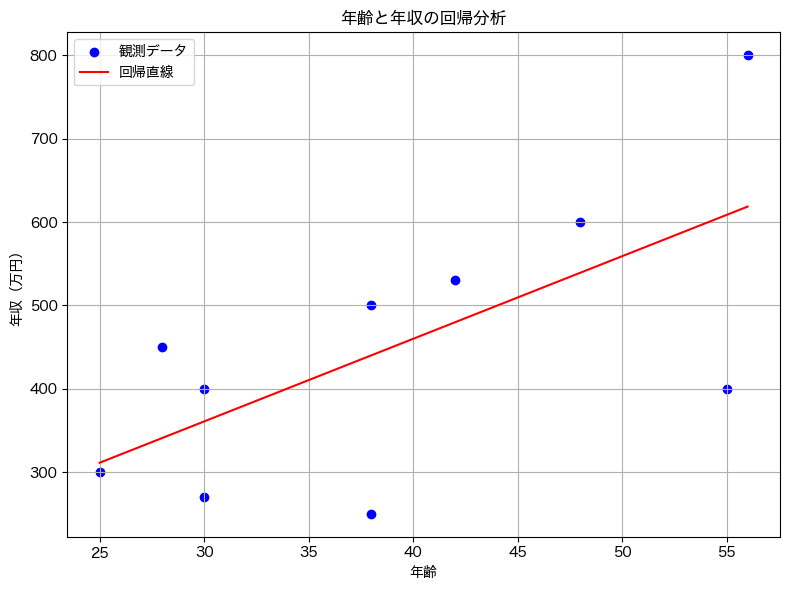

In [55]:
# データの散布図を描画
plt.figure(figsize=(8, 6))
plt.scatter(df["age"], df["income"], color='blue', label='観測データ') 

# 回帰直線を描くための年齢範囲
ages = np.linspace(df["age"].min(), df["age"].max(), 100)
age_df = pd.DataFrame({"age": ages})

# 回帰直線の予測値を取得
predicted_income = model.predict(age_df)

# 回帰直線をプロット
plt.plot(ages, predicted_income, color="red", label="回帰直線")

# 軸ラベルなど
plt.xlabel("年齢")
plt.ylabel("年収（万円）")
plt.title("年齢と年収の回帰分析")
plt.legend()
plt.grid(True)
plt.tight_layout() # 余白を自動調整
plt.show()

### 参考：Seabornを使った表示
* こちらでは，モデル作成もSeabornの内部で行われている（簡単）
* 教科書付属のノートブックのやり方はこちら

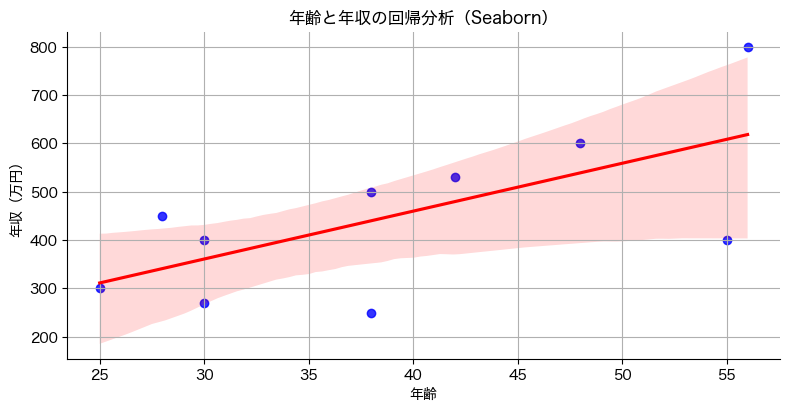

In [56]:
# Seabornのlmplotで回帰直線を図示
sns.lmplot(
    x="age",
    y="income",
    data=df,
    scatter_kws={"color": "blue",},
    line_kws={"color": "red", "label": "回帰直線"},
#    ci=None,          # 信頼区間を表示しない
    ci=95,          # 95%信頼区間を表示する
    height=4,
    aspect=2
)

plt.title("年齢と年収の回帰分析（Seaborn）")
plt.xlabel("年齢")
plt.ylabel("年収（万円）")
plt.grid(True)
plt.show()


## 演習： 耕地面積と販売金額

前回と同じ演習をstatsmodelsを用いて実施してみよう．

次のデータは，北海道のある地域から無作為に抽出した20戸の農家の農産物の2005年度の販売金額と総経営耕地面積のデータである．

In [57]:
farm_sales_data = [
    {"農家番号": 1, "農産物の販売金額": 400, "総経営耕地面積": 60},
    {"農家番号": 2, "農産物の販売金額": 15, "総経営耕地面積": 30},
    {"農家番号": 3, "農産物の販売金額": 480, "総経営耕地面積": 365},
    {"農家番号": 4, "農産物の販売金額": 993, "総経営耕地面積": 190},
    {"農家番号": 5, "農産物の販売金額": 600, "総経営耕地面積": 136},
    {"農家番号": 6, "農産物の販売金額": 150, "総経営耕地面積": 15},
    {"農家番号": 7, "農産物の販売金額": 115, "総経営耕地面積": 37},
    {"農家番号": 8, "農産物の販売金額": 50, "総経営耕地面積": 100},
    {"農家番号": 9, "農産物の販売金額": 0, "総経営耕地面積": 170},
    {"農家番号": 10, "農産物の販売金額": 130, "総経営耕地面積": 70},
    {"農家番号": 11, "農産物の販売金額": 3000, "総経営耕地面積": 783},
    {"農家番号": 12, "農産物の販売金額": 500, "総経営耕地面積": 560},
    {"農家番号": 13, "農産物の販売金額": 200, "総経営耕地面積": 50},
    {"農家番号": 14, "農産物の販売金額": 55, "総経営耕地面積": 35},
    {"農家番号": 15, "農産物の販売金額": 2200, "総経営耕地面積": 595},
    {"農家番号": 16, "農産物の販売金額": 1, "総経営耕地面積": 200},
    {"農家番号": 17, "農産物の販売金額": 900, "総経営耕地面積": 300},
    {"農家番号": 18, "農産物の販売金額": 1000, "総経営耕地面積": 356},
    {"農家番号": 19, "農産物の販売金額": 450, "総経営耕地面積": 155},
    {"農家番号": 20, "農産物の販売金額": 400, "総経営耕地面積": 250}
]

### データフレームにする

In [58]:
df= pd.DataFrame(farm_sales_data)
df.head()

,農家番号,農産物の販売金額,総経営耕地面積
0,1,400,60
1,2,15,30
2,3,480,365
3,4,993,190
4,5,600,136


### (1) 総経営耕地面積を説明変数，販売金額を目的変数として，回帰係数と定数の値を求めよ．

注意：変数を逆にしないように注意すること

In [59]:
# モデルの作成
model = smf.ols(formula="農産物の販売金額 ~ 総経営耕地面積", data=df).fit()

# 結果サマリーの表示
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               農産物の販売金額   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     43.45
Date:                Sat, 21 Jun 2025   Prob (F-statistic):           3.43e-06
Time:                        15:30:21   Log-Likelihood:                -148.57
No. Observations:                  20   AIC:                             301.1
Df Residuals:                      18   BIC:                             303.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -93.2768    140.378     -0.664      0.5

### (2) (1)の結果からわかる回帰式を用いて，耕地面積200に対する販売金額の予測値，耕地面積700に対する販売金額の予測値を求めよ

In [60]:
df_areas = pd.DataFrame(
    [{"総経営耕地面積":200},
     {"総経営耕地面積":700}
     ]
)
# データフレームを渡して予測できる
predicted_sales = model.predict(df_areas)
for area, sales in zip(df_areas["総経営耕地面積"], predicted_sales):
    print(f"面積{area}の予測販売金額：{sales:.2f} 万円")

面積200の予測販売金額：512.72 万円
面積700の予測販売金額：2027.70 万円


### (3) データと回帰直線をグラフで図示せよ

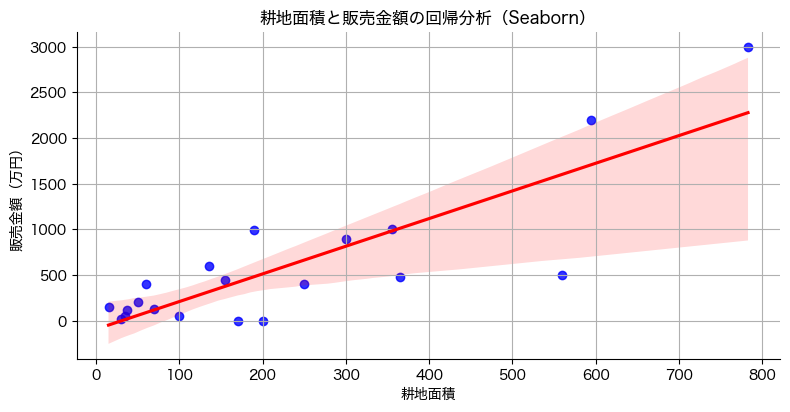

In [61]:
# Seabornのlmplotで回帰直線を図示
sns.lmplot(
    x="総経営耕地面積",
    y="農産物の販売金額",
    data=df,
    scatter_kws={"color": "blue",},
    line_kws={"color": "red", "label": "回帰直線"},
#    ci=None,          # 信頼区間を表示しない
    ci=95,          # 95%信頼区間を表示する
    height=4,
    aspect=2
)

plt.title("耕地面積と販売金額の回帰分析（Seaborn）")
plt.xlabel("耕地面積")
plt.ylabel("販売金額（万円）")
plt.grid(True)
plt.show()
